### Perform Clustering

In [1]:
# Imports
import numpy as np
import os, sys
import matplotlib.pyplot as plt

if "__file__" in globals():
    script_dir = os.path.dirname(os.path.abspath(__file__))
else:
    script_dir = os.getcwd()

utils_dir = os.path.abspath(os.path.join(script_dir, "..", "..", "..", "Utils"))
output_dir = os.path.abspath(os.path.join(script_dir, "..", "Outputs"))

sys.path.append(utils_dir)
from clustering import Cluster
from yaml_processor import load_config, save_config
from data_processing import load_dataset, save_dataset, parameter_plot

config_file = os.path.abspath(os.path.join(script_dir, "..", "configuration.yaml"))
config_global = load_config(config_file)

##### Initialization

In [2]:
dataset_path = os.path.join(output_dir, "datasets")
SS_train, param_train = load_dataset(os.path.join(dataset_path, "Train"))
SS_val, param_val = load_dataset(os.path.join(dataset_path, "Val"))
SS_test, param_test = load_dataset(os.path.join(dataset_path, "Test"))

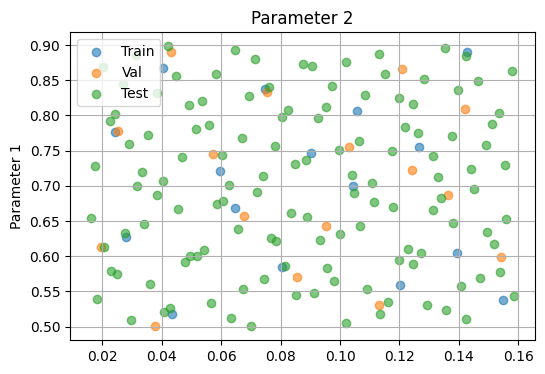

In [3]:
parameter_plot(param_train, param_val, param_test)

###### Choose Clustering Method - (hierarchical, kmeans, dbscan, agglomerative, spectral)

In [4]:
method = "hierarchical"

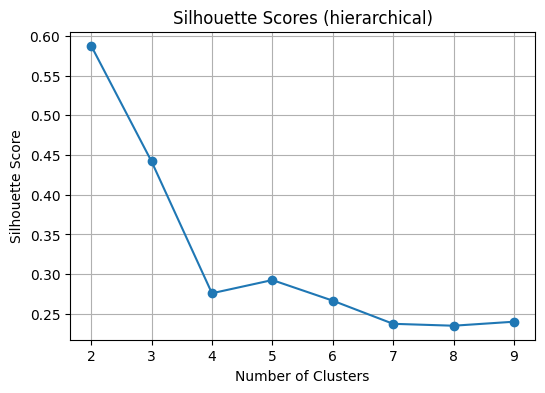

k=2, silhouette=0.588
k=3, silhouette=0.442
k=4, silhouette=0.276
k=5, silhouette=0.293
k=6, silhouette=0.267
k=7, silhouette=0.238
k=8, silhouette=0.235
k=9, silhouette=0.240


In [5]:
clust = Cluster(SS_train[:, 1], param_train)
sil_scores = clust.find_best_k_by_silhouette(method=method, k_range=range(2, 10))

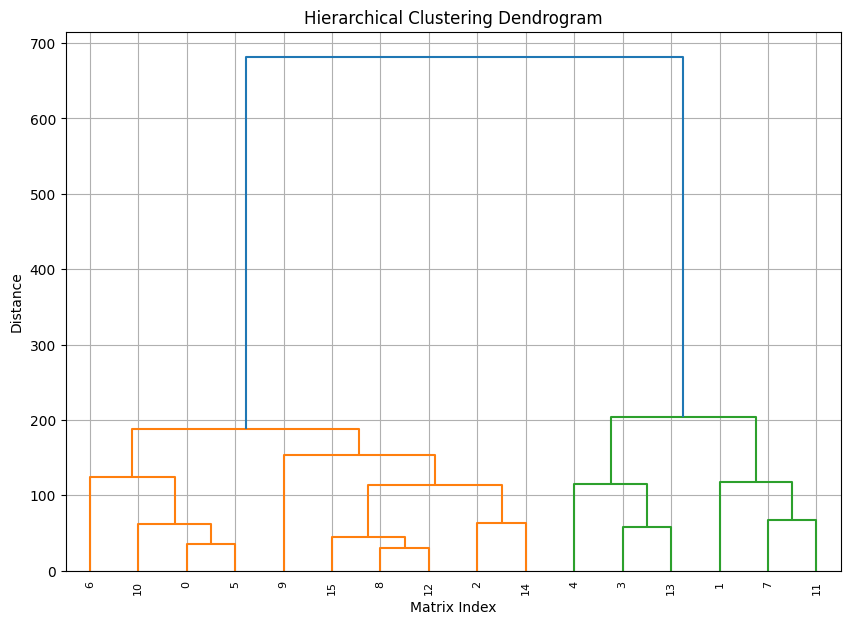

In [6]:
clust.plot_dendrogram()

###### Choose optimal number of clusters

In [7]:
n_clusters = 2

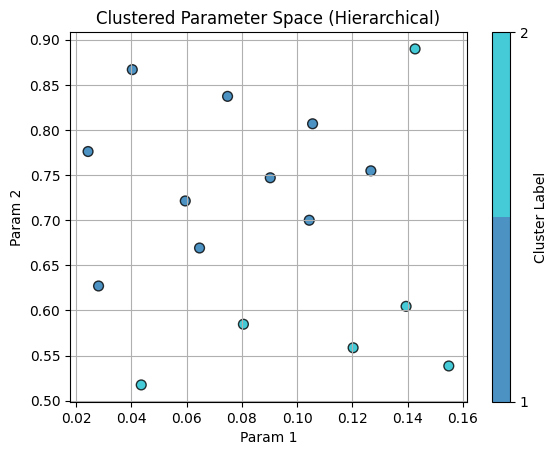

In [8]:
clust.find_clusters(method=method, n_clusters=n_clusters)
clust.plot_clusters_2d()

In [21]:
new_params = clust.generate_from_cluster(
    cluster_idx=0,
    n_samples=50,
    param_gen='gmm'
)

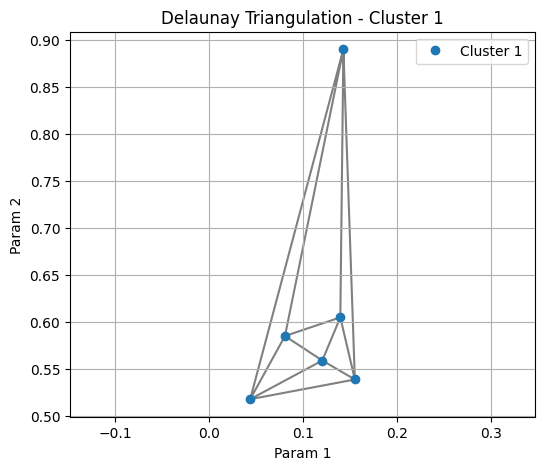

In [10]:
clust.plot_delaunay(1)

In [ ]:
clust.generate_from_cluster(0, 20)

array([[0.05956955, 0.84745349],
       [0.06739944, 0.76743629],
       [0.04763766, 0.79513849],
       [0.09218767, 0.69113914],
       [0.08283923, 0.77868347],
       [0.09224392, 0.68844358],
       [0.08797186, 0.72378153],
       [0.073021  , 0.73797491],
       [0.04794028, 0.68271783],
       [0.09395247, 0.80245313]])

In [27]:
from scipy.spatial import Delaunay
def plot_delaunay(params, show_points=True, show_edges=True, color='k'):
    """
    Plot Delaunay triangulation of a 2D parameter array.

    Parameters:
        params (np.ndarray): shape [N, 2] parameter points
        show_points (bool): whether to show the original points
        show_edges (bool): whether to draw triangle edges
        color (str): edge color
    """
    if params.shape[1] != 2:
        raise ValueError("Delaunay triangulation requires 2D parameters")

    tri = Delaunay(params)
    plt.figure(figsize=(6, 5))
    plt.triplot(params[:, 0], params[:, 1], tri.simplices, color=color)
    if show_points:
        plt.plot(params[:, 0], params[:, 1], 'o', markersize=6)
    plt.title("Delaunay Triangulation of Cluster Parameters")
    plt.xlabel("Param 1")
    plt.ylabel("Param 2")
    plt.grid(True)
    plt.axis('equal')
    plt.show()

    return tri

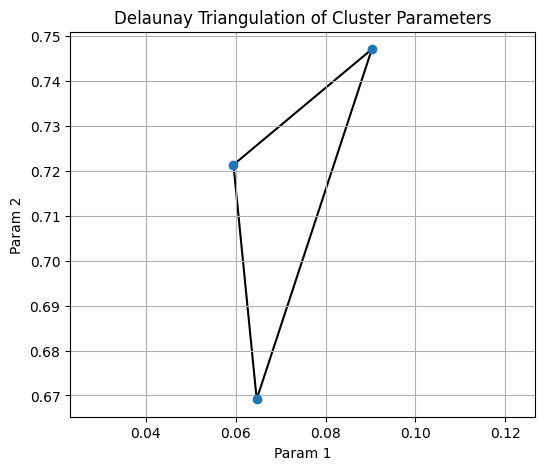

In [42]:
params_k = np.array(clust.get_clustered_data()[1][0])
plot_delaunay(params_k)